In [10]:
import json
import os
import sys
import warnings
from itertools import count

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, ImageOps

import numpy as np


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0


warnings.simplefilter(action="ignore", category=FutureWarning)

In [11]:
#Get training history
with open("EfficientNet_final_training_history_All shannon.json", "r") as f:
    history = json.load(f)

print(history)

vrmse=np.array(history['val_root_mean_squared_error'])
loss=np.array(history['loss'])

print(vrmse)
print(loss)


{'loss': [0.07009227573871613, 0.03420174494385719, 0.029834633693099022, 0.0276525616645813, 0.027216821908950806, 0.027302267029881477], 'mae': [0.19339536130428314, 0.14442741870880127, 0.13252080976963043, 0.1279582381248474, 0.1262872815132141, 0.12638963758945465], 'root_mean_squared_error': [0.2647494673728943, 0.18493713438510895, 0.1727270483970642, 0.16629059612751007, 0.16497521102428436, 0.16523398458957672], 'val_loss': [0.02407899685204029, 0.020817426964640617, 0.01956743560731411, 0.020106421783566475, 0.01979338377714157, 0.02133483998477459], 'val_mae': [0.11140812188386917, 0.10221395641565323, 0.10589475184679031, 0.10983304679393768, 0.1056351512670517, 0.11623035371303558], 'val_root_mean_squared_error': [0.15517409145832062, 0.14428244531154633, 0.13988365232944489, 0.14179711043834686, 0.140688955783844, 0.14606450498104095]}
[0.15517409 0.14428245 0.13988365 0.14179711 0.14068896 0.1460645 ]
[0.07009228 0.03420174 0.02983463 0.02765256 0.02721682 0.02730227]


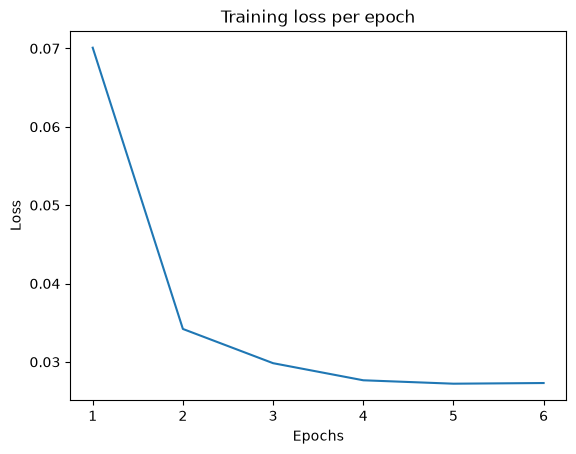

In [12]:
#Plot training loss
import matplotlib.pyplot as plt 
plt.title("Training loss per epoch") 
plt.xlabel("Epochs") 
plt.ylabel("Loss") 
plt.plot(np.arange(1,7), loss) 
plt.show()

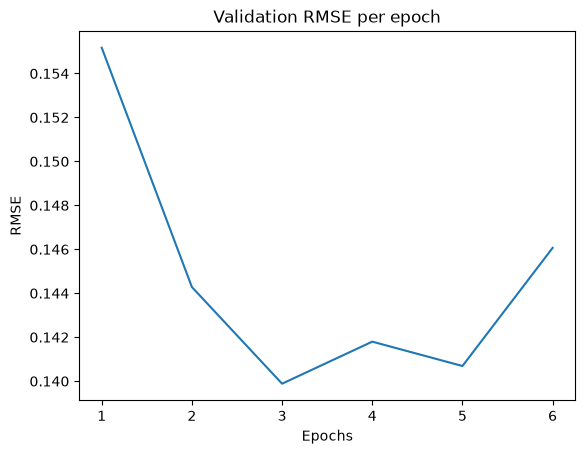

In [13]:
#Plot validation RMSE
import matplotlib.pyplot as plt 
plt.title("Validation RMSE per epoch") 
plt.xlabel("Epochs") 
plt.ylabel("RMSE") 
plt.plot(np.arange(1,7), vrmse) 
plt.show()

In [14]:
#Functions for extracting images/patches for model

#Define these with patches per image = 500
patches_per_image=500

# Patch extraction
def extract_patches(image):
    patches = tf.image.extract_patches(

        images=tf.expand_dims(image, 0),

        sizes=[1, PATCH_SIZE, PATCH_SIZE, 1],
        strides=[1, PATCH_SIZE, PATCH_SIZE, 1],
        rates=[1, 1, 1, 1],
        padding="VALID",
    )

    patches = tf.reshape(
        patches,
        (-1, PATCH_SIZE, PATCH_SIZE, 3)
        )

    #Add padding
    padded = tf.pad(
        patches,
        #no padding on batch, pad 3 on height and width each side, none for channels
        paddings=[
            [0, 0],  
            [3, 3],  
            [3, 3],  
            [0, 0]   
        ],
        mode="CONSTANT",
        constant_values=0
    )

    del patches

    print(padded.shape)
    return padded



#Define loading function for pulling tf dataset elements into memory

def load_image(path, label):

    # Read the file from disk
    image = tf.io.read_file(path)


    # Decode the JPEG
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    #Custom crop function
    shape = tf.shape(image)
    height = shape[0]
    width = shape[1]
    offset_y = (height - 10000) // 2
    offset_x = (width - 10000) // 2
    cropped = image[
        offset_y:offset_y + 10000,
        offset_x:offset_x + 10000,
        :
    ]

    # Extract patches (keep as int for now)
    patches = extract_patches(cropped)

    # Tell TensorFlow the known patch count - this makes for loop work, but requires patch_size to be fixed at 200
    patches.set_shape([2500, 206, 206, 3])

    #Create list of patches to keep
    selected_patches = []

    print('Checking quality of patches')
    # Number of patches to process simultaneously
    chunk_size = 64

    selected_patches = []

    num_patches = patches.shape[0]

    #Iterate through patches in vectorised way for efficiency
    for start in range(0, num_patches, chunk_size):

        end = min(start + chunk_size, num_patches)

        # Small chunk of patches
        patch_chunk = patches[start:end]

        # Convert only this chunk to float
        patch_chunk = tf.image.convert_image_dtype(
            patch_chunk,
            tf.float32
        )

        # Compute std for the whole chunk in parallel
        std = tf.math.reduce_std(
            patch_chunk,
            axis=[1, 2, 3]
        )

        # Keep informative patches
        keep = std > 0.11

        selected_patches.append(
            tf.boolean_mask(patch_chunk, keep)
        )

    # Combine selected patches
    patches = tf.concat(selected_patches, axis=0)

    #RETURN IMAGES TO 0-255 INT FOR EFFICIENTNET INPUT
    patches =tf.cast(tf.round(patches * 255.0), tf.uint8)

    # Enough patches?
    enough_patches = tf.shape(patches)[0] >= patches_per_image

    if enough_patches:

        #Use updated method for genuine deterministic results
        indices = tf.random.experimental.stateless_shuffle(
        tf.range(tf.shape(patches)[0]),
        seed=[1, 2]
        )[:patches_per_image]
        #Keep only the correct patches
        patches = tf.gather(patches, indices)

    else:

        patches = tf.zeros(
            (0, 206, 206, 3),
            dtype=tf.uint8
        )

    print("Image discarded due to insufficient patches")

    del image
    del cropped

    print("Patch tensor shape:", patches.shape)

    return patches, label, enough_patches

In [15]:
#Set function for building model

#Must use patches per image as 1 for this
patches_per_image=1

#Define weights file, and other parameters
weights_file='EfficientNet_Attention_MLP_weights.h5'
epochs=20
PATCH_SIZE=200
dropout=0.2



#Function for building the model, recalled inside each fold
@keras.utils.register_keras_serializable()
class SumPatches(keras.layers.Layer):

    def call(self, inputs):
        return tf.reduce_sum(inputs, axis=1)


def create_model(epochs):

    cnn = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        pooling="avg",
        input_shape=(PATCH_SIZE + 6, PATCH_SIZE + 6, 3)
    )

    cnn.trainable = False

    n_layers = len(cnn.layers)
    n_unfreeze = int(n_layers * 0.3)

    for layer in cnn.layers[-n_unfreeze:]:
        if not isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = True

    mlp = keras.Sequential([
        layers.Input((1280,)),
        layers.Dropout(dropout),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="linear")
    ])

    inputs = keras.Input(
        shape=(patches_per_image, PATCH_SIZE + 6, PATCH_SIZE + 6, 3)
    )

    x = layers.TimeDistributed(cnn)(inputs)

    attention = layers.Dense(128, activation="tanh")(x)
    attention = layers.Dense(1)(attention)
    attention = layers.Softmax(axis=1)(attention)

    x = layers.Multiply()([x, attention])

    x = SumPatches(name="sum_patches")(x)

    outputs = mlp(x)

    full_model = keras.Model(inputs, outputs)

    opt = keras.optimizers.Adam(
        learning_rate=1e-5
    )

    full_model.compile(
        optimizer=opt,
        loss="mse",
        metrics=[
            "mae",
            keras.metrics.RootMeanSquaredError()
        ]
    )

    return full_model

model=create_model(epochs)

#Use saved model weights

model.load_weights(weights_file)



In [16]:
#Get target variable dataframe
df=pd.read_csv('Build model/GBIF_data_output final.csv')
df

,id,bbox,country,code,vegetation,All occurances,All species,All genus,All family,All shannon,...,Birds genus,Birds family,Birds shannon,Birds simpson,Insects occurances,Insects species,Insects genus,Insects family,Insects shannon,Insects simpson
0,01WCN,"[-179.27373550867588, 64.81655030472247, -178....",Russia,RU,0.011539,350,13,9,1,1.851326,...,9.0,1.0,1.851326,0.793116,0,NaN,NaN,NaN,NaN,NaN
1,01WDN,"[-179.1879174559298, 65.62092379757253, -178.9...",Russia,RU,0.000000,353,15,10,2,1.944638,...,9.0,1.0,1.858947,0.794070,0,NaN,NaN,NaN,NaN,NaN
2,01WFM,"[-174.93824181397912, 63.87577717070686, -172....",Russia,RU,0.292356,464,3,3,3,0.199219,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
3,01WFN,"[-174.24319571437613, 64.77074135158136, -172....",Russia,RU,0.409852,421,1,1,1,-0.000000,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
4,02WMS,"[-170.99973405843116, 64.8898512428375, -170.7...",Russia,RU,0.000000,454,4,4,4,0.094362,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3598,31UES,"[2.999712175851301, 50.46142894340954, 3.85557...",Belgium,BE,59.416461,875465,114,105,80,2.093783,...,44.0,25.0,2.884154,0.881440,82349,95.0,91.0,50.0,3.294565,0.895857
3599,31UET,"[2.999706370881351, 51.35263389325745, 4.61138...",Belgium,BE,22.789715,22960,131,121,74,3.720579,...,62.0,36.0,2.864775,0.899002,2323,87.0,80.0,49.0,1.736284,0.570619
3600,31UFQ,"[4.35791076985194, 48.62982157570405, 5.904572...",Belgium,BE,73.438388,4659,149,138,70,1.832654,...,56.0,34.0,3.420381,0.939717,1510,140.0,126.0,39.0,4.394654,0.982794
3601,31UFR,"[4.382684363173013, 49.5368401770802, 5.923509...",Belgium,BE,89.779520,99646,153,143,87,3.300694,...,56.0,32.0,2.944671,0.875449,12237,148.0,124.0,55.0,3.874707,0.943706


In [29]:
#Begin analysis based on forward pass
#(Using a manual 'for loop', as tensorflow timedistributed not optimised for laptop CPU)

#Choose an input image and image filepath
image='T17MQS.jpg'
image_path='Build model/jpeg_files/'


#Set patches per image to 500 and extract all patches from image
patches_per_image=500
image_path=image_path+image
patches=load_image(image_path,0)

#Check if enough patches
if patches[2]==True:
    print('Enough patches')

#Filter to just the patches themselves
patches=patches[0]

#Now redefine to patches per image =1, and create model using preloaded weights
#Model now accepts one patch at a time.
patches_per_image=1
model=create_model(epochs)
model.load_weights(weights_file)


feature_layer=model.layers[1]
attention_layer=model.layers[4]

#Define a model that is a subset of the original, that outputs the embeddings.
#This outputs the embeddings for a single patch
embedding_model = keras.Model(
    inputs=model.input,
    outputs=feature_layer.output
)

print(embedding_model.summary())

#Set up list for storing embeddings of all 500 patches
embeddings=[]

#Go through all 500 patches, apply embedding model one at a time, append embeddings to list
for patch in patches:
    patch=tf.stack([patch], axis=0)
    patch=tf.stack([patch], axis=0)
    print(patch.shape)
    embedding=embedding_model.predict(patch)
    print(embedding)
    embeddings.append(embedding[0][0])
    






(2500, 206, 206, 3)
Checking quality of patches
Image discarded due to insufficient patches
Patch tensor shape: (500, 206, 206, 3)
Enough patches


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 1, 206, 206, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 1, 1280)        │     4,049,571 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 3,037,820 (11.59 MB)

 Non-trainable params: 1,011,751 (3.86 MB)

None
(1, 1, 206, 206, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
[[[-0.03247456  0.04316197 -0.17684038 ... -0.19552743 -0.06338564
    0.96415985]]]
(1, 1, 206, 206, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
[[[-0.10507654 -0.16413087 -0.1887176  ... -0.1330559  -0.00501883
    0.9404799 ]]]
(1, 1, 206, 206, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[[-0.22670156  0.1391227  -0.0265584  ... -0.18840727 -0.16304862
    0.6291131 ]]]
(1, 1, 206, 206, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[[-0.19609451 -0.0342733  -0.22347362 ... -0.14845219 -0.11171371
    0.6612073 ]]]
(1, 1, 206, 206, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
[[[-0.21258761  0.01375896  0.12005667 ... -0.15142873 -0.14835785
    1.317861  ]]]
(1, 1, 206, 206, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[[-0.15117921 -0.06261267 -0.06961565 ... -0.12001321 -0.1175101
    0.77303135]]]
(1, 1, 206, 206, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[[-0.15857477 -0.14896728 -0.20817786 ... -0.14682639 -0.14074032
    0.74700785

In [30]:
#Use embeddings to create prediction

#Convert embeddings to tensor and add batch dimension
t_embeddings=tf.convert_to_tensor(embeddings)
t_embeddings=tf.stack([t_embeddings], axis=0)
t_embeddings.shape

#Reset patches per image to 500 and rebuild model from weights, so now all layers expect input of 500 not 1
patches_per_image=500
model=create_model(epochs)
model.load_weights(weights_file)

#Create model that is a subset, taking embeddings as input. Just attention layers onwards. 
#Define input shape - one embedding per patch
new_input = keras.Input(shape=(500, 1280))
# Add the attention network, by going through the layers of the original model and adding one at a time
attention = model.layers[2](new_input)       
attention = model.layers[3](attention)       
attention = model.layers[4](attention)       
# Apply attention weights to embeddings
weighted = model.layers[5]([new_input, attention])
# Sum the 500 patches -> single 1280-dimensional embedding
pooled = model.layers[6](weighted)
# MLP
output = model.layers[7](pooled)
#Compile final new model, by stacking layers together taken from original model
attention_mlp = keras.Model(
    inputs=new_input,
    outputs=output
)

#Use model to make prediction for tile
prediction=attention_mlp.predict(t_embeddings)[0][0]

#Rescale prediction to original scale of target variable, and get actual value for comparison
scale_factor=float(df['All shannon'].max())
prediction=prediction * scale_factor
actual=float(df[df['id']==image[1:-4]]['All shannon'].values[0])

print('Predicted:', prediction)
print('Actual:', actual)





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Predicted: 3.5174615
Actual: 3.961134269106114


In [31]:
#Create model for extracting attention weights, to see most important patches

#Create model that is subset of model from last step, using the same input but outputting the final attention layer
attention_layer=attention_mlp.layers[3]
#Use this to get attention weightings
attention_model=keras.Model(
    inputs=attention_mlp.input,
    outputs=attention
)


#Use attention model to get weights for all 500 patches
attention_weight_tensor=attention_model(t_embeddings)

#Extract patch weights from tensor into single dimensional list
attention_weights=[]
for weight in attention_weight_tensor[0]:
    attention_weights.append(float(weight[0].numpy()))

print(type(attention_weights))
print(attention_weights)

#Sort the attention weights for patches
sorted_attention_weights=sorted(attention_weights)
print(sorted_attention_weights)

#get highest and lowest weights
best1=sorted_attention_weights[-1]
best2=sorted_attention_weights[-2]
best3=sorted_attention_weights[-3]
worst1=sorted_attention_weights[0]
worst2=sorted_attention_weights[1]
worst3=sorted_attention_weights[2]

#Find indexes of those weights
best1=attention_weights.index(best1)
best2=attention_weights.index(best2)
best3=attention_weights.index(best3)
worst1=attention_weights.index(worst1)
worst2=attention_weights.index(worst2)
worst3=attention_weights.index(worst3)

print('Highest attention = ', best1)
print('2nd highest attention = ', best2)
print('Lowest attention = ', worst1)

print([image,actual, prediction,best1,best2,best3,worst1,worst2,worst3])

<class 'list'>
[0.0006499820156022906, 0.004770957864820957, 0.0008748515392653644, 0.000688368862029165, 0.0007344597252085805, 0.001322522759437561, 0.0009165490046143532, 0.001095239887945354, 0.0028857209254056215, 0.0016908715479075909, 0.001566931838169694, 0.00345161696895957, 0.0031352443620562553, 0.0011511383345350623, 0.003194135148078203, 0.0009755910723470151, 0.0009234653552994132, 0.002077861689031124, 0.0013105608522891998, 0.0005514150834642351, 0.003055424662306905, 0.003294894704595208, 0.00328894448466599, 0.0012639315100386739, 0.002656700322404504, 0.0026825263630598783, 0.00206766533665359, 0.0014870966551825404, 0.0025833097752183676, 0.0038938247598707676, 0.0006406730972230434, 0.002209019148722291, 0.0032341917976737022, 0.003226676257327199, 0.005102322902530432, 0.0008581941947340965, 0.0007237367099151015, 0.0006266949931159616, 0.0017716450383886695, 0.0015851014759391546, 0.0028176468331366777, 0.002066642278805375, 0.0005541093996725976, 0.0034438651055

In [32]:
#Create function for showing patch
def show_patch(image, patch_index):
    image_path='Build model/jpeg_files/'+image
    patches=load_image(image_path,0)
    if patches[2]==True:
        print('Enough patches')
        patches=patches[0]
        patches=tf.stack([patches], axis=0)
        print(patches.shape)
        plt.imshow(patches[0][patch_index])

In [33]:
#Go through top 3 then worst 3 patches, showing each as an image

(2500, 206, 206, 3)
Checking quality of patches
Image discarded due to insufficient patches
Patch tensor shape: (500, 206, 206, 3)
Enough patches
(1, 500, 206, 206, 3)


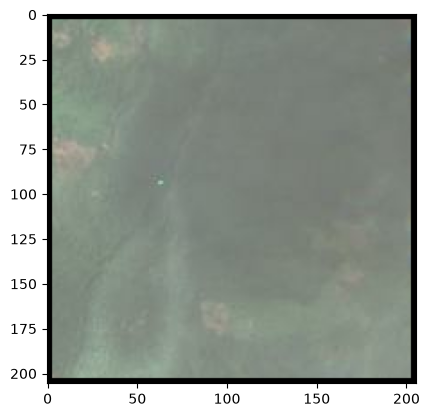

In [34]:
show_patch(image, best1)

(2500, 206, 206, 3)
Checking quality of patches
Image discarded due to insufficient patches
Patch tensor shape: (500, 206, 206, 3)
Enough patches
(1, 500, 206, 206, 3)


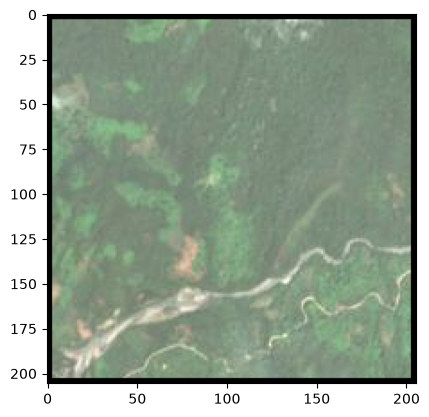

In [35]:
show_patch(image, best2)

(2500, 206, 206, 3)
Checking quality of patches
Image discarded due to insufficient patches
Patch tensor shape: (500, 206, 206, 3)
Enough patches
(1, 500, 206, 206, 3)


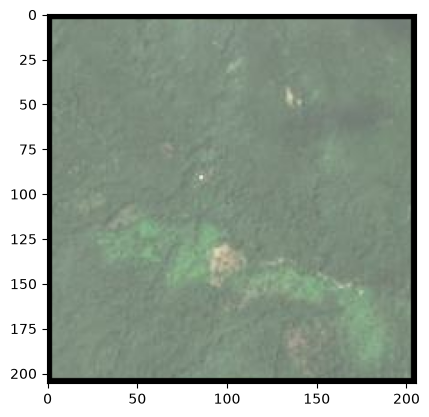

In [36]:
show_patch(image, best3)

(2500, 206, 206, 3)
Checking quality of patches
Image discarded due to insufficient patches
Patch tensor shape: (500, 206, 206, 3)
Enough patches
(1, 500, 206, 206, 3)


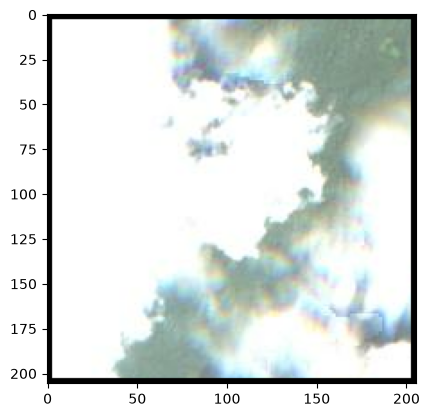

In [37]:
show_patch(image, worst1)

(2500, 206, 206, 3)
Checking quality of patches
Image discarded due to insufficient patches
Patch tensor shape: (500, 206, 206, 3)
Enough patches
(1, 500, 206, 206, 3)


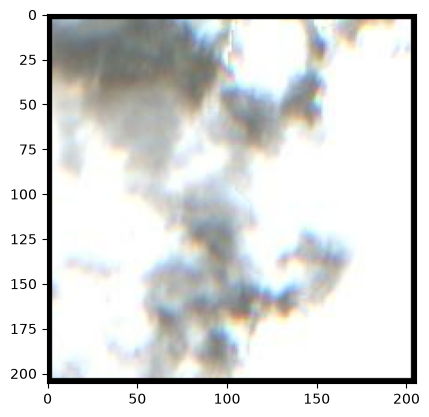

In [38]:
show_patch(image, worst2)

(2500, 206, 206, 3)
Checking quality of patches
Image discarded due to insufficient patches
Patch tensor shape: (500, 206, 206, 3)
Enough patches
(1, 500, 206, 206, 3)


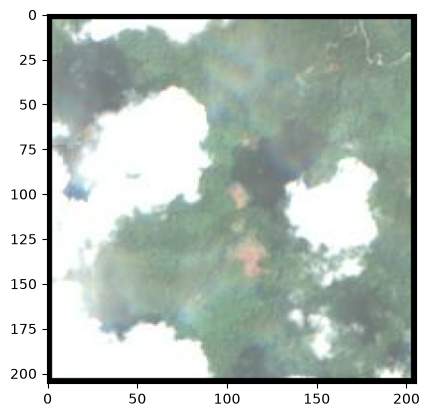

In [39]:
show_patch(image, worst3)